### First practical implementation: a tiny Keras RNN

In [1]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model = Sequential([
    SimpleRNN(10),
    Dense(1)
])

model.summary()

I0000 00:00:1790991573.598201      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790991573.601836      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Our first real project

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [3]:
# Create the sequence:
data = np.arange(10, 20000)

print(data)

[   10    11    12 ... 19997 19998 19999]


In [4]:
# Now create input-output pairs.
X = []
y = []

sequence_length = 5

for i in range(len(data) - sequence_length):

    X.append(data[i:i + sequence_length])

    y.append(data[i + sequence_length])

In [5]:
print("X:")
print(X[:5])

print("\ny:")
print(y[:5])

X:
[array([10, 11, 12, 13, 14]), array([11, 12, 13, 14, 15]), array([12, 13, 14, 15, 16]), array([13, 14, 15, 16, 17]), array([14, 15, 16, 17, 18])]

y:
[np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]


In [6]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(19985, 5)
(19985,)


In [7]:
# You'll have:

# X → (86, 5)
# y → (86,)

# But RNN needs:

# (batch, timesteps, features)

# Currently:

# (batch, timesteps)

# So we add the feature dimension:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [8]:
print(X.shape)

(19985, 5, 1)


### Visualize our training data

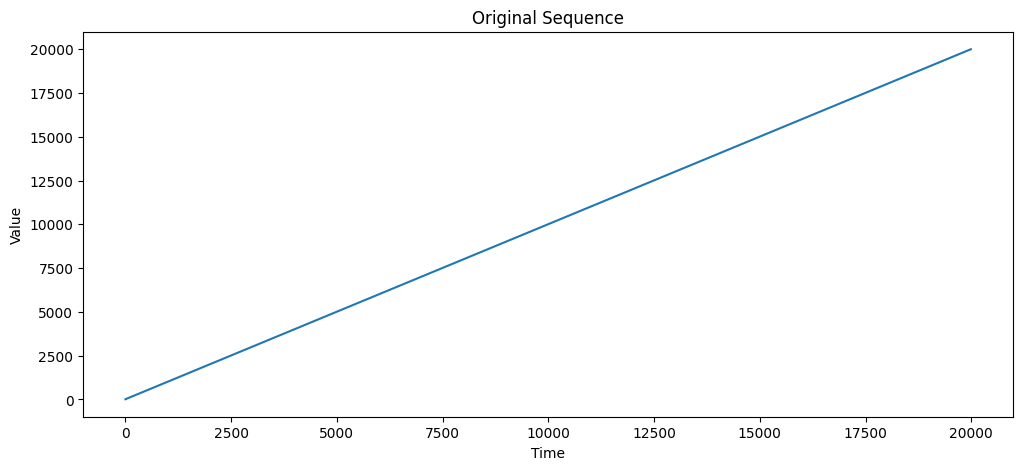

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(data)

plt.title("Original Sequence")
plt.xlabel("Time")
plt.ylabel("Value")

plt.show()

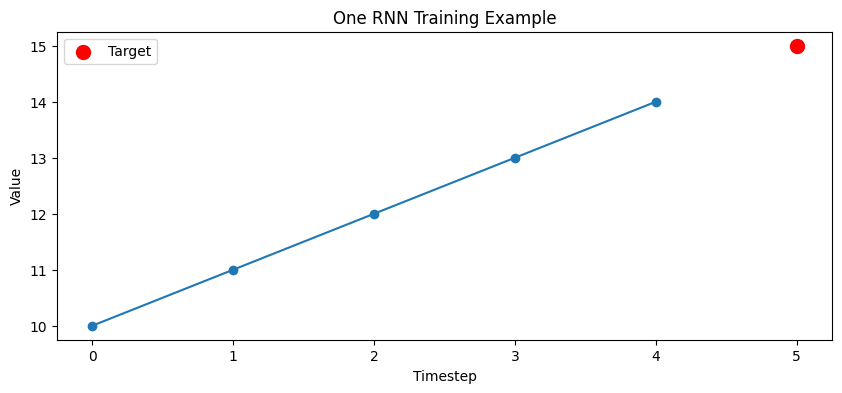

In [10]:
plt.figure(figsize=(10, 4))

plt.plot(
    range(5),
    X[0, :, 0],
    marker='o'
)

plt.scatter(
    5,
    y[0],
    color='red',
    s=100,
    label='Target'
)

plt.title("One RNN Training Example")

plt.xlabel("Timestep")
plt.ylabel("Value")

plt.legend()

plt.show()

In [11]:
model = Sequential([
    
    SimpleRNN(
        units=10,
        activation='tanh',
        input_shape=(5, 1)
    ),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
# Compile the model with optimizer, loss, and metrics
model.compile(
    optimizer='adam',
    loss='mse',          # Mean Squared Error
    metrics=['mae']      # Mean Absolute Error
)

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0,
)


In [15]:
history = model.fit(
    X,
    y,
    epochs=100000,
    batch_size=16,
    verbose=1,
    callbacks = early_stop,
    validation_split = 0.2
)

Epoch 1/100000
  66/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 85882110.6667 - mae: 8111.6748

I0000 00:00:1790991578.605433      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 85388776.0000 - mae: 8005.4546 - val_loss: 325061792.0000 - val_mae: 17992.5020
Epoch 2/100000
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 85214696.0000 - mae: 7994.5850 - val_loss: 324670752.0000 - val_mae: 17981.6738
Epoch 3/100000
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 85041128.0000 - mae: 7983.6973 - val_loss: 324280064.0000 - val_mae: 17970.7695
Epoch 4/100000
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 84867720.0000 - mae: 7972.8496 - val_loss: 323889440.0000 - val_mae: 17959.9414
Epoch 5/100000
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 84694264.0000 - mae: 7962.0161 - val_loss: 323498496.0000 - val_mae: 17949.0039
Epoch 6/100000
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 84521272.0000 - mae: 7951.1553 - val_loss: 323108384.0000 - val_mae: 17938.1777
Epoch 7/100000
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 84348504.0000 - mae: 7940.3115 - val_loss: 322718560.0000 - val_mae: 1792

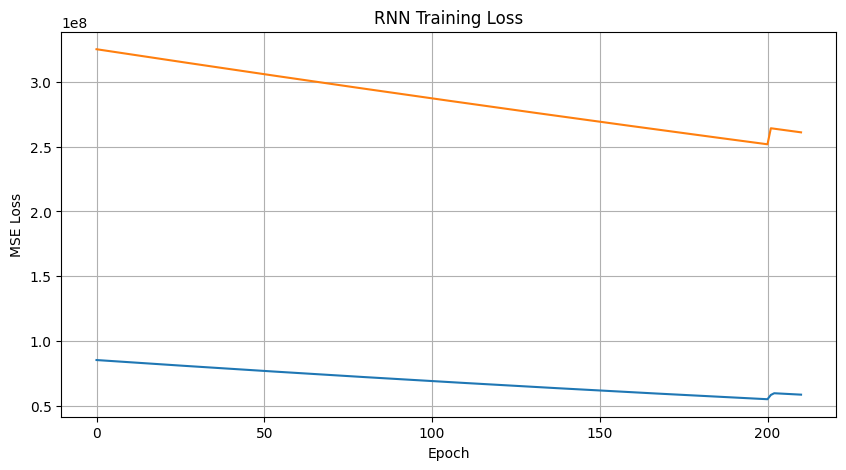

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("RNN Training Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.grid()

plt.show()

In [17]:
test_sequence = np.array([
    [91, 92, 93, 94, 95]
])

test_sequence = test_sequence.reshape(1, 5, 1)

prediction = model.predict(test_sequence)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
[[105.47754]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


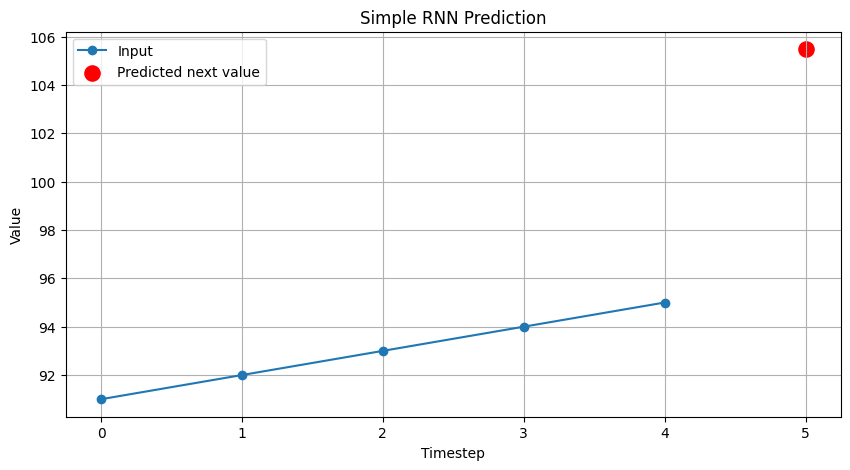

In [18]:
prediction = model.predict(test_sequence)[0][0]

input_values = [91, 92, 93, 94, 95]

plt.figure(figsize=(10, 5))

plt.plot(
    range(5),
    input_values,
    marker='o',
    label='Input'
)

plt.scatter(
    5,
    prediction,
    color='red',
    s=120,
    label='Predicted next value'
)

plt.xticks(range(6))

plt.xlabel("Timestep")
plt.ylabel("Value")

plt.title("Simple RNN Prediction")

plt.legend()

plt.grid()

plt.show()